<a href="https://colab.research.google.com/github/Bhuvana272006/FUTURE_ML_02/blob/main/classification_model_all_tickets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import zipfile

# ML
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
zip_path = "all_tickets_processed_improved_v3.csv.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall()

df = pd.read_csv("all_tickets_processed_improved_v3.csv")

In [ ]:
print(df.head())


                                            Document    Topic_group
0  connection with icon icon dear please setup ic...       Hardware
1  work experience user work experience user hi w...         Access
2  requesting for meeting requesting meeting hi p...       Hardware
3  reset passwords for external accounts re expir...         Access
4  mail verification warning hi has got attached ...  Miscellaneous


In [ ]:
print(df.columns)

Index(['Document', 'Topic_group'], dtype='object')


In [ ]:
df.dropna(inplace=True)

In [ ]:
X = df['Document']        # text column
y = df['Topic_group']    # label column

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test_vec)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8457357859531772
                       precision    recall  f1-score   support

               Access       0.89      0.89      0.89      1455
Administrative rights       0.78      0.76      0.77       342
           HR Support       0.83      0.84      0.84      2107
             Hardware       0.83      0.84      0.83      2760
     Internal Project       0.89      0.82      0.86       451
        Miscellaneous       0.80      0.83      0.82      1400
             Purchase       0.95      0.89      0.92       497
              Storage       0.90      0.86      0.88       556

             accuracy                           0.85      9568
            macro avg       0.86      0.84      0.85      9568
         weighted avg       0.85      0.85      0.85      9568



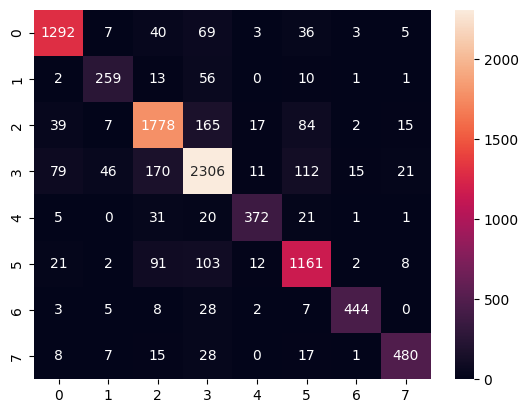

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

In [ ]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))

In [ ]:
%%writefile app.py
import streamlit as st
import pickle

# Load model and vectorizer
model = pickle.load(open("model.pkl", "rb"))
vectorizer = pickle.load(open("vectorizer.pkl", "rb"))

# Title
st.title("🎫 IT Support Ticket Classifier")

st.write("Enter your issue below and get predicted category")

# Input box
user_input = st.text_area("Enter Ticket Text")

# Predict button
if st.button("Predict"):
    if user_input.strip() != "":
        vectorized_input = vectorizer.transform([user_input])
        prediction = model.predict(vectorized_input)

        st.success(f"Predicted Category: {prediction[0]}")
    else:
        st.warning("Please enter some text")

Writing app.py
